## This is the softmax workbook for ECE C147/C247 Assignment #2

Please follow the notebook linearly to implement a softmax classifier.

Please print out the workbook entirely when completed.

The goal of this workbook is to give you experience with training a softmax classifier.

In [7]:
import random
import numpy as np
from utils.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000, num_dev=500):
    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the linear classifier. These are the same steps as we used for the
    SVM, but condensed to a single function.  
    """
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cifar-10-batches-py' # You need to update this line
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
    
    # subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]
    mask = np.random.choice(num_training, num_dev, replace=False)
    X_dev = X_train[mask]
    y_dev = y_train[mask]
    
    # Preprocessing: reshape the image data into rows
    X_train = np.reshape(X_train, (X_train.shape[0], -1))
    X_val = np.reshape(X_val, (X_val.shape[0], -1))
    X_test = np.reshape(X_test, (X_test.shape[0], -1))
    X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))
    
    # Normalize the data: subtract the mean image
    mean_image = np.mean(X_train, axis = 0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image
    X_dev -= mean_image
    
    # add bias dimension and transform into columns
    X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
    X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
    X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])
    
    return X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev


# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev = get_CIFAR10_data()
print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('dev data shape: ', X_dev.shape)
print('dev labels shape: ', y_dev.shape)

Train data shape:  (49000, 3073)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3073)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3073)
Test labels shape:  (1000,)
dev data shape:  (500, 3073)
dev labels shape:  (500,)


## Training a softmax classifier.

The following cells will take you through building a softmax classifier.  You will implement its loss function, then subsequently train it with gradient descent.  Finally, you will choose the learning rate of gradient descent to optimize its classification performance.

In [9]:
from nndl import Softmax

In [29]:
# Declare an instance of the Softmax class.  
# Weights are initialized to a random value.
# Note, to keep people's first solutions consistent, we are going to use a random seed.

np.random.seed(1)

num_classes = len(np.unique(y_train))
num_features = X_train.shape[1]

softmax = Softmax(dims=[num_classes, num_features])

#### Softmax loss

In [30]:
## Implement the loss function of the softmax using a for loop over
#  the number of examples

loss = softmax.loss(X_train, y_train)

In [31]:
print(loss)

2.327760702804874


## Question: 

You'll notice the loss returned by the softmax is about 2.3 (if implemented correctly).  Why does this make sense?

Hint: Connect to probability.

## Answer:

We're looking at the average of the negative logarithm of the probabilities. There are 10 classes, on average we expect to have ~0.1 probability for the correct class initially. natural log of 10 is about 2.3, therefore this is almost exactly what we expect.

#### Softmax gradient

In [32]:
## Calculate the gradient of the softmax loss in the Softmax class.
# For convenience, we'll write one function that computes the loss
#   and gradient together, softmax.loss_and_grad(X, y)
# You may copy and paste your loss code from softmax.loss() here, and then
#   use the appropriate intermediate values to calculate the gradient.

loss, grad = softmax.loss_and_grad(X_dev,y_dev)

# Compare your gradient to a gradient check we wrote. 
# You should see relative gradient errors on the order of 1e-07 or less if you implemented the gradient correctly.
softmax.grad_check_sparse(X_dev, y_dev, grad)

numerical: 0.034928 analytic: 0.034928, relative error: 7.019919e-07
numerical: 0.267839 analytic: 0.267839, relative error: 5.174990e-08
numerical: 1.356864 analytic: 1.356864, relative error: 6.420613e-09
numerical: 1.164343 analytic: 1.164343, relative error: 6.343462e-09
numerical: 0.502163 analytic: 0.502163, relative error: 6.476979e-08
numerical: 2.159721 analytic: 2.159721, relative error: 7.368732e-09
numerical: -0.866250 analytic: -0.866250, relative error: 4.729011e-09
numerical: -1.211365 analytic: -1.211365, relative error: 5.341012e-09
numerical: 1.692624 analytic: 1.692624, relative error: 6.894366e-09
numerical: -2.459303 analytic: -2.459303, relative error: 2.390640e-08


## A vectorized version of Softmax

To speed things up, we will vectorize the loss and gradient calculations.  This will be helpful for stochastic gradient descent.

In [33]:
import time

In [37]:
## Implement softmax.fast_loss_and_grad which calculates the loss and gradient
#    WITHOUT using any for loops.  

# Standard loss and gradient
tic = time.time()
loss, grad = softmax.loss_and_grad(X_dev, y_dev)
toc = time.time()
print('Normal loss / grad_norm: {} / {} computed in {}s'.format(loss, np.linalg.norm(grad, 'fro'), toc - tic))

tic = time.time()
loss_vectorized, grad_vectorized = softmax.fast_loss_and_grad(X_dev, y_dev)
toc = time.time()
print('Vectorized loss / grad: {} / {} computed in {}s'.format(loss_vectorized, np.linalg.norm(grad_vectorized, 'fro'), toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference in loss / grad: {} /{} '.format(loss - loss_vectorized, np.linalg.norm(grad - grad_vectorized)))

# You should notice a speedup with the same output.

Normal loss / grad_norm: 2.3393592316203606 / 355.62450083961147 computed in 0.028314828872680664s
Vectorized loss / grad: 2.339359231620361 / 355.62450083961147 computed in 0.001987934112548828s
difference in loss / grad: -4.440892098500626e-16 /2.3593417445809625e-13 


## Stochastic gradient descent

We now implement stochastic gradient descent.  This uses the same principles of gradient descent we discussed in class, however, it calculates the gradient by only using examples from a subset of the training set (so each gradient calculation is faster).

iteration 0 / 1500: loss 2.3793049120913907
iteration 100 / 1500: loss 2.1008247685633528
iteration 200 / 1500: loss 1.9906505134987105
iteration 300 / 1500: loss 1.912985387315555
iteration 400 / 1500: loss 1.8741374417104932
iteration 500 / 1500: loss 1.9583991632981048
iteration 600 / 1500: loss 1.8157140466788626
iteration 700 / 1500: loss 1.9248296125982782
iteration 800 / 1500: loss 1.863933090074073
iteration 900 / 1500: loss 1.8030275263430633
iteration 1000 / 1500: loss 1.777713842036182
iteration 1100 / 1500: loss 1.8284823510829702
iteration 1200 / 1500: loss 1.7632603674840883
iteration 1300 / 1500: loss 1.7653801002671372
iteration 1400 / 1500: loss 1.8792940222523293
That took 1.6507840156555176s


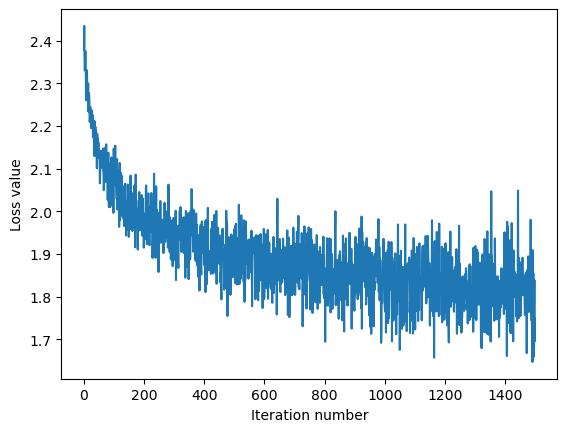

In [59]:
# Implement softmax.train() by filling in the code to extract a batch of data
# and perform the gradient step.
import time


tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took {}s'.format(toc - tic))

plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

### Evaluate the performance of the trained softmax classifier on the validation data.

In [60]:
## Implement softmax.predict() and use it to compute the training and testing error.

y_train_pred = softmax.predict(X_train)
print('training accuracy: {}'.format(np.mean(np.equal(y_train,y_train_pred), )))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: {}'.format(np.mean(np.equal(y_val, y_val_pred)), ))

training accuracy: 0.3826734693877551
validation accuracy: 0.383


## Optimize the softmax classifier

In [61]:
np.finfo(float).eps

2.220446049250313e-16

Got val accuracy 0.28 for learning rate 1e-05
Got val accuracy 0.413 for learning rate 1e-06
Got val accuracy 0.407 for learning rate 1e-07
Got val accuracy 0.331 for learning rate 1e-08
Got val accuracy 0.3 for learning rate 5e-09


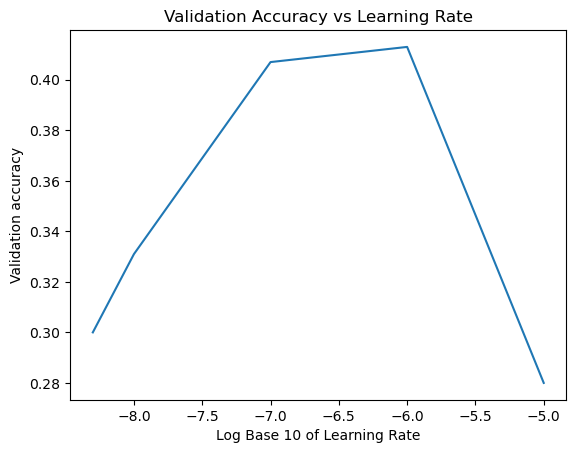

In [66]:
# ================================================================ #
# YOUR CODE HERE:
#   Train the Softmax classifier with different learning rates and 
#     evaluate on the validation data.
#   Report:
#     - The best learning rate of the ones you tested, determined by best validation accuracy.  
#     - The best validation accuracy.
#     - Select the model that achieved the best validation accuracy and report
#       its accuracy on the test set.
# ================================================================ #
lrs = [1e-5, 1e-6, 1e-7, 1e-8, 5*1e-9]
val_acc = []
for lr in lrs:
    softmax = Softmax()
    softmax.train(X_train, y_train, lr, num_iters=3000, verbose=False)
    y_val_pred = softmax.predict(X_val)
    acc = np.mean(np.equal(y_val, y_val_pred))
    val_acc.append(acc)
    print(f"Got val accuracy {acc} for learning rate {lr}")
    
from math import log10
plt.plot([log10(lr) for lr in lrs], val_acc)
plt.title("Validation Accuracy vs Learning Rate")

plt.xlabel('Log Base 10 of Learning Rate')
plt.ylabel('Validation accuracy')

plt.show()

# ================================================================ #
# END YOUR CODE HERE
# ================================================================ #


According to my results, the best learning rate is probably between 1e-6 and 1e-7. 1e-6 performed best for me, only slightly better than 1e-7. As expected. increasing number of iterations did not change much since the model more or less converges within the current num_iterations.